# LoraE Results and Visualization
This notebook provides a comprehensive view of the LoraE model performance across various scenarios and adaptive behaviors.

In [22]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

# Paths
model_dir = 'trained_models/LoraE_invi_visi_alpha_128/test/'
video_dir = 'visualizations/LoraE_invi_visi_alpha_128/'
master_csv = 'result/master_summary.csv'

scenarios = [
    'all_ignorant',
    'all_aware',
    'ignorant_to_aware_step25',
    'mixed_5050'
]

def load_results(scenarios, behaviors):
    results = []
    for scenario in scenarios:
        for behavior in behaviors:
            filename = f"seperate_{scenario}_{behavior}.json"
            filepath = os.path.join(model_dir, filename)
            
            if os.path.exists(filepath):
                with open(filepath, 'r') as f:
                    data = json.load(f)
                summary = data.get('summary', {})
                if summary.get('num_episodes', 0) >= 500:
                    res = {
                        'Scenario': scenario,
                        'Behavior': behavior,
                        'SR': summary.get('success_rate'),
                        'CR': summary.get('collision_rate'),
                        'TR': summary.get('timeout_rate'),
                        'NavTime': summary.get('avg_nav_time'),
                        'PathLen': summary.get('avg_path_length'),
                        'Uncertainty': summary.get('avg_uncertainty'),
                        'AvgLoRA': summary.get('avg_lora_scale', 'N/A'),
                        'Friendly': summary.get('avg_discrepancy_aware', 'N/A'),
                        'Ignorant': summary.get('avg_discrepancy_ignorant', 'N/A'),
                        'All': summary.get('avg_discrepancy_all', 'N/A')
                    }
                    results.append(res)
            else:
                print(f"File not found: {filepath}")
    return pd.DataFrame(results)

def generate_video_grid(scenarios, behaviors):
    html_code = "<div style='display: grid; grid-template-columns: repeat({n_cols}, 1fr); gap: 10px; text-align: center;'>".format(n_cols=len(behaviors)+1)
    html_code += "<div style='background: #eee;'>Scenario \\ Behavior</div>"
    for b in behaviors:
        html_code += f"<div style='font-weight: bold; background: #eee;'>{b}</div>"

    for s in scenarios:
        html_code += f"<div style='font-weight: bold; display: flex; align-items: center; justify-content: center; background: #fafafa;'>{s}</div>"
        for b in behaviors:
            video_found = False
            # Try Success then Collision
            for status in ['Success', 'Collision']:
                video_filename = f"seperate_{s}_{b}_ep0_{status}.mp4"
                video_path = os.path.join(video_dir, video_filename)
                if os.path.exists(video_path):
                    html_code += f"<div><video width='100%' controls><source src='{video_path}' type='video/mp4'></video></div>"
                    video_found = True
                    break
            if not video_found:
                html_code += "<div style='border: 1px solid #ccc; height: 100px; display: flex; align-items: center; justify-content: center;'>Video Missing</div>"
    html_code += "</div>"
    return HTML(html_code)

## 1. Performance with Ground Truth Knowledge
This section compares the baseline behaviors with ground-truth switching and adaptive logic.

In [23]:
gt_behaviors = ['always_off', 'always_on', 'switching_gt', 'adaptive_gt']
df_gt = load_results(scenarios, gt_behaviors)

print("### Results Table (Ground Truth Knowledge)")
display(df_gt)

print("\n### Video Grid (Ground Truth Knowledge)")
display(generate_video_grid(scenarios, gt_behaviors))

### Results Table (Ground Truth Knowledge)


,Scenario,Behavior,SR,CR,TR,NavTime,PathLen,Uncertainty,AvgLoRA,Friendly,Ignorant,All
0,all_ignorant,always_off,0.980,0.020,0.0,17.238776,24.423235,0.098775,0.000000,0.000000,0.466474,0.466474
1,all_ignorant,always_on,0.520,0.480,0.0,10.671154,16.153334,0.146177,1.000000,0.000000,0.049283,0.049283
2,all_ignorant,switching_gt,0.980,0.020,0.0,17.183673,24.370073,0.099427,0.011125,0.000000,0.465025,0.465025
3,all_ignorant,adaptive_gt,0.980,0.020,0.0,17.183673,24.370073,0.099427,0.011125,0.000000,0.465025,0.465025
4,all_aware,always_off,1.000,0.000,0.0,16.759000,24.206217,0.104190,0.000000,0.439519,0.000000,0.439519
5,all_aware,always_on,0.996,0.004,0.0,10.364458,17.789703,0.147789,1.000000,0.022833,0.000000,0.022833
6,all_aware,switching_gt,0.996,0.004,0.0,10.364458,17.789703,0.147789,1.000000,0.022833,0.000000,0.022833
7,all_aware,adaptive_gt,0.996,0.004,0.0,10.364458,17.789703,0.147789,1.000000,0.022833,0.000000,0.022833
8,ignorant_to_aware_step25,always_off,0.988,0.012,0.0,17.188259,24.453312,0.100117,0.000000,0.559317,-0.003320,0.436564
9,ignorant_to_aware_step25,always_on,0.912,0.088,0.0,11.156798,17.898075,0.148393,1.000000,0.003936,0.110645,0.046128



### Video Grid (Ground Truth Knowledge)


## 2. Performance vs LoRA Scale (Sweep)
This plot shows how fixed LoRA scales impact Success and Collision rates.

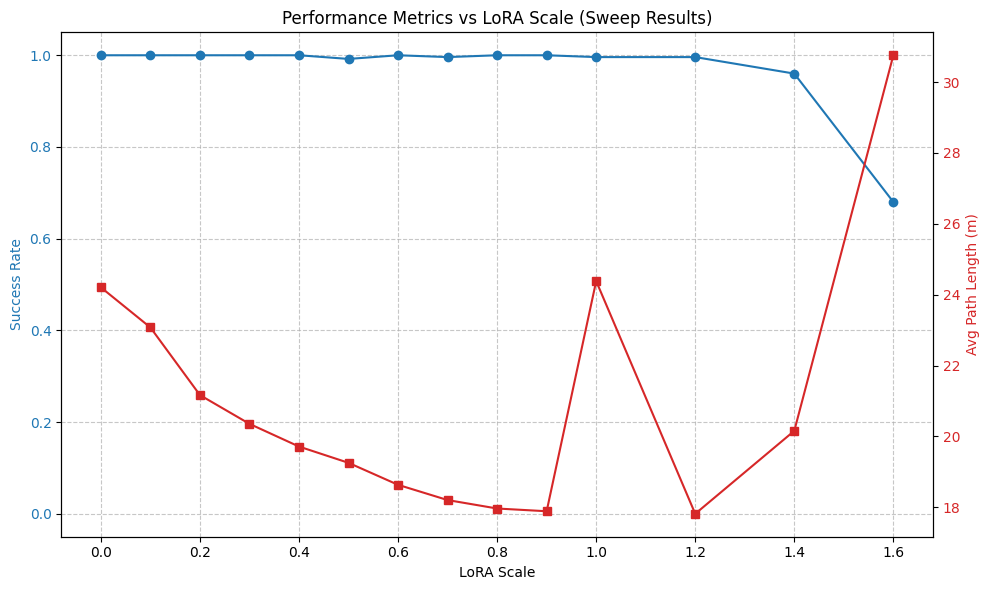

,lora_scale,success_rate,avg_path_length,total_episodes
8,0.0,1.000,24.206217,250
12,0.1,1.000,23.074343,250
2,0.2,1.000,21.166880,250
3,0.3,1.000,20.355243,250
4,0.4,1.000,19.715016,250
13,0.5,0.992,19.255525,250
5,0.6,1.000,18.635182,250
0,0.7,0.996,18.205236,250
7,0.8,1.000,17.966814,250
1,0.9,1.000,17.889718,250


In [24]:
import glob
import re

# Settings
min_episodes = 50

# Find all scale-specific CSV files in the test directory
csv_files = glob.glob(os.path.join(model_dir, 'evaluation_data_scale_*.csv'))
results = []

for csv_path in csv_files:
    match = re.search(r'evaluation_data_scale_([\d\.]+)\.csv', os.path.basename(csv_path))
    if match:
        scale = float(match.group(1))
        df = pd.read_csv(csv_path)
        
        # Calculate counts accurately (matching plot_lora_results.py)
        successes = df['Success Times'].count()
        collisions = df['Collision Times'].count()
        timeouts = df['Timeout Times'].count()
        total = successes + collisions + timeouts
        
        if total < min_episodes:
            print(f"Skipping scale {scale}: Only {total} episodes (min_episodes={min_episodes})")
            continue

        results.append({
            'lora_scale': scale,
            'success_rate': successes / total,
            'avg_path_length': df['Path Length'].mean(),
            'total_episodes': total
        })

if results:
    df_sweep = pd.DataFrame(results).sort_values(by='lora_scale')
    
    # Prepare lists for dual-axis plotting (matching plot_lora_results.py style)
    scales = df_sweep['lora_scale'].tolist()
    sr = df_sweep['success_rate'].tolist()
    pl = df_sweep['avg_path_length'].tolist()
    
    # Dual axis plot
    fig, ax1 = plt.subplots(figsize=(10, 6))
    color = 'tab:blue'
    ax1.set_xlabel('LoRA Scale')
    ax1.set_ylabel('Success Rate', color=color)
    ax1.plot(scales, sr, 'o-', color=color, label='Success Rate')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Avg Path Length (m)', color=color)
    ax2.plot(scales, pl, 's-', color=color, label='Avg Path Length')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Performance Metrics vs LoRA Scale (Sweep Results)')
    fig.tight_layout()
    plt.show()
    
    display(df_sweep[['lora_scale', 'success_rate', 'avg_path_length', 'total_episodes']])
else:
    print("No valid scale-specific CSV data found in ", model_dir)

## 3. Comparison: GT vs Discrepancy (Estimated Knowledge)
Comparing performance when using Ground Truth vs Discrepancy-based estimation for Switching and Adaptive behaviors.

In [25]:
comp_behaviors = ['switching_gt', 'switching_discrepancy', 'adaptive_gt', 'adaptive_discrepancy']
df_comp = load_results(scenarios, comp_behaviors)

print("### Comparison Table (GT vs Discrepancy)")
display(df_comp)

print("\n### Comparison Video Grid (GT vs Discrepancy)")
display(generate_video_grid(scenarios, comp_behaviors))

### Comparison Table (GT vs Discrepancy)


,Scenario,Behavior,SR,CR,TR,NavTime,PathLen,Uncertainty,AvgLoRA,Friendly,Ignorant,All
0,all_ignorant,switching_gt,0.980,0.020,0.0,17.183673,24.370073,0.099427,0.011125,0.000000,0.465025,0.465025
1,all_ignorant,switching_discrepancy,0.980,0.020,0.0,17.171429,24.357008,0.099529,0.011789,0.000000,0.465605,0.465605
2,all_ignorant,adaptive_gt,0.980,0.020,0.0,17.183673,24.370073,0.099427,0.011125,0.000000,0.465025,0.465025
3,all_ignorant,adaptive_discrepancy,0.972,0.028,0.0,16.931070,24.153749,0.100414,0.025376,0.000000,0.459661,0.459661
4,all_aware,switching_gt,0.996,0.004,0.0,10.364458,17.789703,0.147789,1.000000,0.022833,0.000000,0.022833
5,all_aware,switching_discrepancy,1.000,0.000,0.0,16.867000,24.308239,0.104451,0.012144,0.458033,0.000000,0.458033
6,all_aware,adaptive_gt,0.996,0.004,0.0,10.364458,17.789703,0.147789,1.000000,0.022833,0.000000,0.022833
7,all_aware,adaptive_discrepancy,1.000,0.000,0.0,16.897000,24.337437,0.104752,0.025942,0.484110,0.000000,0.484110
8,ignorant_to_aware_step25,switching_gt,0.984,0.016,0.0,14.558943,21.859348,0.122202,0.578230,0.201141,-0.001368,0.150840
9,ignorant_to_aware_step25,switching_discrepancy,0.988,0.012,0.0,17.095142,24.357765,0.100648,0.012738,0.557861,-0.001486,0.434733



### Comparison Video Grid (GT vs Discrepancy)
